# Data Preparation

In this notebook the goal is to prepare the dataset (csv or excel) to train the Random Forest Classifier for land cover classification. The dataset would be composed of : 

- annual fractional cover (bs, pv, npv)
- RGB
- NDVI, NDWI, NDWI, EVI
- DEM (elevation)
- seasonal fractional cover

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from dask.distributed import Client as DaskClient
from odc.geo.geom import BoundingBox
from odc.stac import configure_s3_access, load
from pystac_client import Client

In [2]:
# Configure S3 access in Dask and outside
configure_s3_access(aws_unsigned=True)

# Set up a Dask client
dask_client = DaskClient(
    n_workers=2,
    threads_per_worker=16,
    memory_limit="30GB",
)

/srv/conda/envs/notebook/lib/python3.10/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 43787 instead
  warnings.warn(


In [3]:
catalog = "https://stac.staging.digitalearthpacific.io"
client = Client.open(catalog)

In [87]:
# Bounding box 

# TRAINING AREA 
# over Viti Levu, Fiji : left=177.2, bottom=-18.3, right=178.8, top=-17.2
# over Rarotonga, Cook Island : left=-159.85, bottom=-21.28, right=-159.7, top=-21.19
# over Majuro, Marshall Island : left=171, bottom=7.05, right=171.4, top=7.25
# over Ngerulmud, Palau Island : left=134.2, bottom=7.11, right=134.66, top=7.75

# TESTING AREA 
# over Vanua Levu, Fiji (label available) : left=178.55, bottom=-17.2, right=179.98, top=-15.85
# over Nouméa, New-Calédonia (no label) : left=166.35, bottom=-22.33, right=166.56, top=-22.16

bbox = BoundingBox(left=166.35, bottom=-22.33, right=166.56, top=-22.16)
bbox.explore()

## ANNUAL FRACTIONAL COVER

In [88]:
items = client.search(
    collections=["dep_ls_fc_summary_annual"],
    bbox=bbox,
).item_collection()

# Load the data
chunks = dict(x=2048, y=2048)
data = load(items, chunks=chunks, measurements=["bs_pc_50", "pv_pc_50", "npv_pc_50"], bbox=bbox)

# compute loads into memory
fc = data.where(data != 255, np.nan).compute()

print(fc)

<xarray.Dataset> Size: 6MB
Dimensions:      (time: 1, y: 679, x: 780)
Coordinates:
  * y            (y) float64 5kB -2.515e+06 -2.515e+06 ... -2.535e+06 -2.535e+06
  * x            (x) float64 6kB 1.82e+06 1.82e+06 ... 1.843e+06 1.843e+06
    spatial_ref  int32 4B 3832
  * time         (time) datetime64[ns] 8B 2024-01-01
Data variables:
    bs_pc_50     (time, y, x) float32 2MB 13.0 14.0 12.0 12.0 ... nan nan nan
    pv_pc_50     (time, y, x) float32 2MB 79.0 85.0 82.0 79.0 ... nan nan nan
    npv_pc_50    (time, y, x) float32 2MB 11.0 8.0 10.0 10.0 ... nan nan nan nan


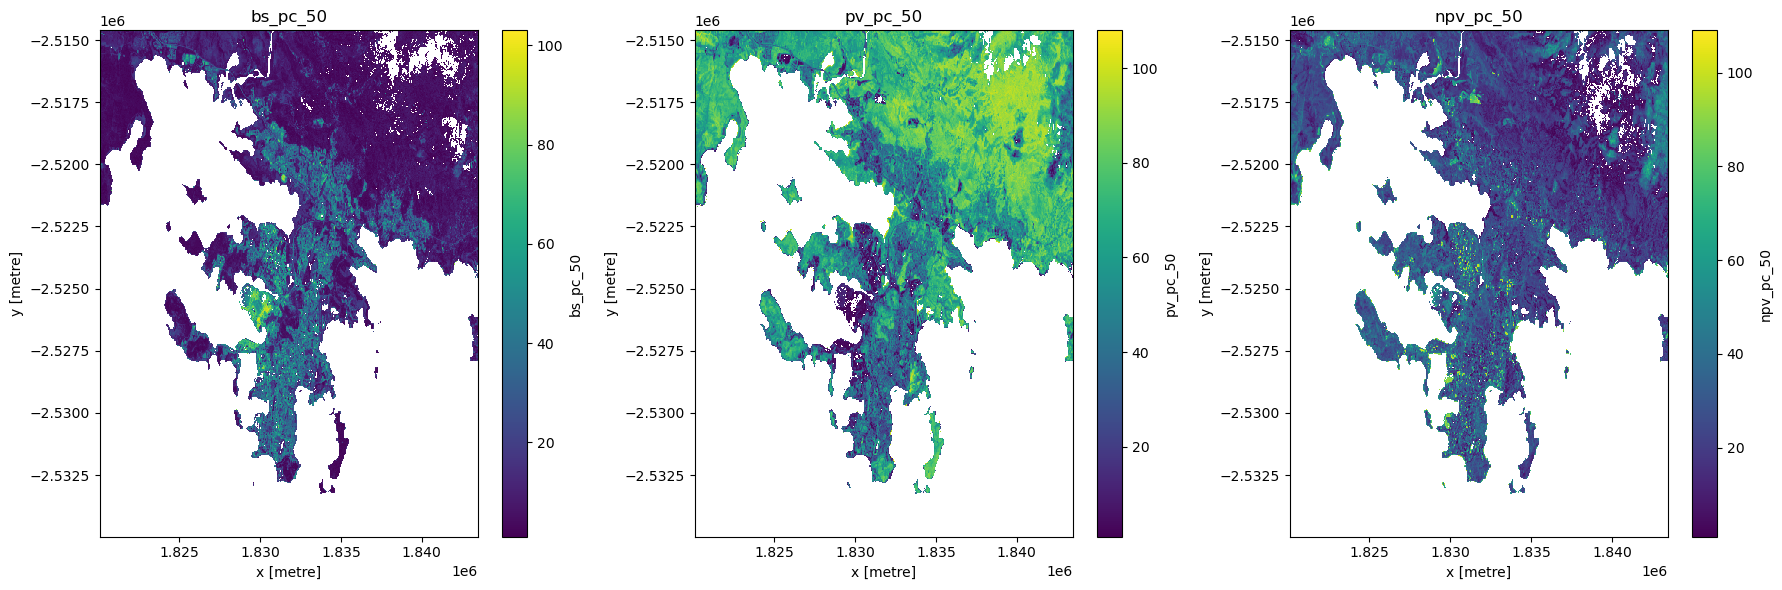

In [89]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, band in enumerate(fc.data_vars):
    fc[band].isel(time=0).plot(ax=axes[i], cmap="viridis")
    axes[i].set_title(band)

plt.tight_layout()
plt.show()

## RGB + INDEXES (NDVI, NDWI, NDBI, ...)

In [90]:
items = client.search(
    collections=["dep_s2_geomad"],
    bbox=bbox,
    datetime="2024",
).item_collection()

# Load the data
chunks = dict(x=2048, y=2048)
data = load(
    items,
    chunks=chunks,
    like=fc.odc.geobox,
    measurements=["red", "blue", "green", "nir08", "swir16", "emad", "smad", "bcmad"],
)
spectral = data.where(data != 0, np.nan)

print(spectral)

<xarray.Dataset> Size: 28MB
Dimensions:      (time: 1, y: 679, x: 780)
Coordinates:
  * y            (y) float64 5kB -2.515e+06 -2.515e+06 ... -2.535e+06 -2.535e+06
  * x            (x) float64 6kB 1.82e+06 1.82e+06 ... 1.843e+06 1.843e+06
    spatial_ref  int32 4B 3832
  * time         (time) datetime64[ns] 8B 2024-01-01
Data variables:
    red          (time, y, x) float64 4MB dask.array<chunksize=(1, 679, 780), meta=np.ndarray>
    blue         (time, y, x) float64 4MB dask.array<chunksize=(1, 679, 780), meta=np.ndarray>
    green        (time, y, x) float64 4MB dask.array<chunksize=(1, 679, 780), meta=np.ndarray>
    nir08        (time, y, x) float64 4MB dask.array<chunksize=(1, 679, 780), meta=np.ndarray>
    swir16       (time, y, x) float64 4MB dask.array<chunksize=(1, 679, 780), meta=np.ndarray>
    emad         (time, y, x) float32 2MB dask.array<chunksize=(1, 679, 780), meta=np.ndarray>
    smad         (time, y, x) float32 2MB dask.array<chunksize=(1, 679, 780), meta=np.ndar

In [91]:
def add_indices(data: xr.Dataset) -> xr.Dataset:
    """
    Add common spectral indices to a Sentinel-2 xarray Dataset.
    Works with bands: red, green, blue, nir08, swir16.
    """
    spectral_bands = data[["red", "green", "blue", "nir08", "swir16"]]

    nodata = spectral_bands.red == 0

    # Do index calculation on scaled float values
    scaled = (spectral_bands / 10000).clip(0, 1).astype("float32")
    scaled = scaled.where(~nodata, np.nan)

    # NDVI = (NIR - Red) / (NIR + Red)
    data["ndvi"] = (scaled["nir08"] - scaled["red"]) / (scaled["nir08"] + scaled["red"])

    # MNDWI = (Green - SWIR) / (Green + SWIR)
    data["mndwi"] = (scaled["green"] - scaled["swir16"]) / (scaled["green"] + scaled["swir16"])

    # EVI = 2.5 * (NIR - Red) / (NIR + 6*Red - 7.5*Blue + 1)
    data["evi"] = (2.5 * (scaled["nir08"] - scaled["red"])) / (
        scaled["nir08"] + 6 * scaled["red"] - 7.5 * scaled["blue"] + 1
    )

    # NDBI (Normalized Difference Built-up Index) = (SWIR - NIR) / (SWIR + NIR)
    data["ndbi"] = (scaled["swir16"] - scaled["nir08"]) / (scaled["swir16"] + scaled["nir08"])

    # We don't need the scaled values any more
    del scaled

    return data

In [92]:
# Compute loads into memory
spectral_with_indices = add_indices(spectral).compute()
spectral_with_indices

<xarray.Dataset> Size: 36MB
Dimensions:      (time: 1, y: 679, x: 780)
Coordinates:
  * y            (y) float64 5kB -2.515e+06 -2.515e+06 ... -2.535e+06 -2.535e+06
  * x            (x) float64 6kB 1.82e+06 1.82e+06 ... 1.843e+06 1.843e+06
    spatial_ref  int32 4B 3832
  * time         (time) datetime64[ns] 8B 2024-01-01
Data variables:
    red          (time, y, x) float64 4MB 182.0 178.0 196.0 ... 445.0 466.0
    blue         (time, y, x) float64 4MB 158.0 158.0 170.0 ... 689.0 713.0
    green        (time, y, x) float64 4MB 343.0 368.0 362.0 ... 582.0 598.0
    nir08        (time, y, x) float64 4MB 2.197e+03 2.426e+03 ... 444.0 460.0
    swir16       (time, y, x) float64 4MB 624.0 628.0 669.0 ... 442.0 462.0
    emad         (time, y, x) float32 2MB 696.2 772.5 ... 1.227e+03 1.244e+03
    smad         (time, y, x) float32 2MB 0.00121 0.001031 ... 0.01709 0.007931
    bcmad        (time, y, x) float32 2MB 0.07624 0.07463 ... 0.2891 0.2817
    ndvi         (time, y, x) float32 2MB 0.847 0.8633 ... -0.001125 -0.006479
    mndwi        (time, y, x) float32 2MB -0.2906 -0.261 ... 0.1367 0.1283
    evi          (time, y, x) float32 2MB 0.4162 0.4566 ... -0.0003146 -0.001897
    ndbi         (time, y, x) float32 2MB -0.5576 -0.5887 ... -0.002257 0.002169

In [93]:
spectral_with_indices.ndvi.odc.explore(cmap="RdYlGn")

In [94]:
# Merge the annual FC in

final_data = xr.merge([spectral_with_indices, fc])
final_data

<xarray.Dataset> Size: 42MB
Dimensions:      (time: 1, y: 679, x: 780)
Coordinates:
  * y            (y) float64 5kB -2.515e+06 -2.515e+06 ... -2.535e+06 -2.535e+06
  * x            (x) float64 6kB 1.82e+06 1.82e+06 ... 1.843e+06 1.843e+06
    spatial_ref  int32 4B 3832
  * time         (time) datetime64[ns] 8B 2024-01-01
Data variables: (12/15)
    red          (time, y, x) float64 4MB 182.0 178.0 196.0 ... 445.0 466.0
    blue         (time, y, x) float64 4MB 158.0 158.0 170.0 ... 689.0 713.0
    green        (time, y, x) float64 4MB 343.0 368.0 362.0 ... 582.0 598.0
    nir08        (time, y, x) float64 4MB 2.197e+03 2.426e+03 ... 444.0 460.0
    swir16       (time, y, x) float64 4MB 624.0 628.0 669.0 ... 442.0 462.0
    emad         (time, y, x) float32 2MB 696.2 772.5 ... 1.227e+03 1.244e+03
    ...           ...
    mndwi        (time, y, x) float32 2MB -0.2906 -0.261 ... 0.1367 0.1283
    evi          (time, y, x) float32 2MB 0.4162 0.4566 ... -0.0003146 -0.001897
    ndbi         (time, y, x) float32 2MB -0.5576 -0.5887 ... -0.002257 0.002169
    bs_pc_50     (time, y, x) float32 2MB 13.0 14.0 12.0 12.0 ... nan nan nan
    pv_pc_50     (time, y, x) float32 2MB 79.0 85.0 82.0 79.0 ... nan nan nan
    npv_pc_50    (time, y, x) float32 2MB 11.0 8.0 10.0 10.0 ... nan nan nan nan

## SEASONNAL FRACTIONAL COVER 

In [95]:
####################################################################
# LOAD DATA 
####################################################################

# Set up common loading arguments
common_arguments = dict(
    chunks=dict(x=2048, y=2048),
    groupby="solar_day",
    like=final_data.odc.geobox 
)

# WOFL Landsat-8 Image --> USED AS THE MASK TO REMOVE CLOUD
wofls_items = client.search(
    collections=["dep_ls_wofl"],
    bbox=bbox,
    datetime="2024",
).item_collection()

wofls = load(wofls_items, **common_arguments) 

# FC Landsat-8 Image 
fc_items = client.search(
    collections=["dep_ls_fc"],
    bbox=bbox,
    datetime="2024-01-01/2024-12-31",
).item_collection()

# Load the data
fc_daily = load(fc_items, **common_arguments)

#######################################################################
# MERGE DATA AND MASK CLOUDS
#######################################################################
merged = fc_daily.merge(wofls)
masked = merged.where(merged['water'] != 1, np.nan)
clean = masked.where(masked != 255)
clean = clean.drop_vars(["water", "ue"])

clean

<xarray.Dataset> Size: 597MB
Dimensions:      (time: 94, y: 679, x: 780)
Coordinates:
  * y            (y) float64 5kB -2.515e+06 -2.515e+06 ... -2.535e+06 -2.535e+06
  * x            (x) float64 6kB 1.82e+06 1.82e+06 ... 1.843e+06 1.843e+06
  * time         (time) datetime64[ns] 752B 2024-01-03T22:57:20.821440 ... 20...
    spatial_ref  int32 4B 3832
Data variables:
    bs           (time, y, x) float32 199MB dask.array<chunksize=(1, 679, 780), meta=np.ndarray>
    pv           (time, y, x) float32 199MB dask.array<chunksize=(1, 679, 780), meta=np.ndarray>
    npv          (time, y, x) float32 199MB dask.array<chunksize=(1, 679, 780), meta=np.ndarray>

In [96]:
#########################################################################
# GROUP BY SEASON
#########################################################################

# Resample by groups of 4 months. Compute into memory.
fc_seasonal = clean.resample(time="4MS").median(dim="time").compute()
fc_seasonal

fc_jan_apr = fc_seasonal.sel(time="2024-01-01").squeeze()
fc_may_aug = fc_seasonal.sel(time="2024-05-01").squeeze()
fc_sep_dec = fc_seasonal.sel(time="2024-09-01").squeeze()

seasonal = {
    "jan_apr": fc_jan_apr,
    "may_aug": fc_may_aug,
    "sep_dec": fc_sep_dec
}

In [97]:
# Add the seasonal data onto the final data array
for season in ["jan_apr", "may_aug", "sep_dec"]:
    final_data[f"bs_med_{season}"] = seasonal[season]["bs"]
    final_data[f"pv_med_{season}"] = seasonal[season]["pv"]
    final_data[f"npv_med_{season}"] = seasonal[season]["npv"]

final_data

<xarray.Dataset> Size: 61MB
Dimensions:          (time: 1, y: 679, x: 780)
Coordinates:
  * y                (y) float64 5kB -2.515e+06 -2.515e+06 ... -2.535e+06
  * x                (x) float64 6kB 1.82e+06 1.82e+06 ... 1.843e+06 1.843e+06
    spatial_ref      int32 4B 3832
  * time             (time) datetime64[ns] 8B 2024-01-01
Data variables: (12/24)
    red              (time, y, x) float64 4MB 182.0 178.0 196.0 ... 445.0 466.0
    blue             (time, y, x) float64 4MB 158.0 158.0 170.0 ... 689.0 713.0
    green            (time, y, x) float64 4MB 343.0 368.0 362.0 ... 582.0 598.0
    nir08            (time, y, x) float64 4MB 2.197e+03 2.426e+03 ... 460.0
    swir16           (time, y, x) float64 4MB 624.0 628.0 669.0 ... 442.0 462.0
    emad             (time, y, x) float32 2MB 696.2 772.5 ... 1.244e+03
    ...               ...
    bs_med_may_aug   (y, x) float32 2MB 19.5 21.5 26.0 28.5 ... 96.0 98.0 99.0
    pv_med_may_aug   (y, x) float32 2MB 64.5 66.0 66.0 65.5 ... 48.0 29.0 39.5
    npv_med_may_aug  (y, x) float32 2MB 21.0 5.5 7.5 8.5 ... 84.5 82.5 73.0 76.5
    bs_med_sep_dec   (y, x) float32 2MB 14.0 15.5 12.5 13.5 ... 79.0 71.5 71.0
    pv_med_sep_dec   (y, x) float32 2MB 67.0 70.0 68.0 66.0 ... 35.5 31.0 30.5
    npv_med_sep_dec  (y, x) float32 2MB 13.5 11.0 13.5 17.0 ... 74.5 61.0 96.5

In [98]:
final_data.bs_med_jan_apr.odc.explore(cmap="RdYlGn")

## DEM 

In [99]:
e84_catalog = "https://earth-search.aws.element84.com/v1/"
dem_collection = "cop-dem-glo-30"
e84_client = Client.open(e84_catalog)

dem_items = e84_client.search(
    collections=[dem_collection],
    bbox=bbox
).item_collection()

dem_data = load(
    items=dem_items,
    like=final_data.odc.geobox
).squeeze()

dem_data

<xarray.Dataset> Size: 2MB
Dimensions:      (y: 679, x: 780)
Coordinates:
  * y            (y) float64 5kB -2.515e+06 -2.515e+06 ... -2.535e+06 -2.535e+06
  * x            (x) float64 6kB 1.82e+06 1.82e+06 ... 1.843e+06 1.843e+06
    spatial_ref  int32 4B 3832
    time         datetime64[ns] 8B 2021-04-22
Data variables:
    data         (y, x) float32 2MB 1.442 1.891 2.207 2.59 ... 0.0 0.0 0.0 0.0

In [100]:
dem_data.data.odc.explore()

In [101]:
final_data["dem"] = dem_data.data
final_data.data_vars

Data variables:
    red              (time, y, x) float64 4MB 182.0 178.0 196.0 ... 445.0 466.0
    blue             (time, y, x) float64 4MB 158.0 158.0 170.0 ... 689.0 713.0
    green            (time, y, x) float64 4MB 343.0 368.0 362.0 ... 582.0 598.0
    nir08            (time, y, x) float64 4MB 2.197e+03 2.426e+03 ... 460.0
    swir16           (time, y, x) float64 4MB 624.0 628.0 669.0 ... 442.0 462.0
    emad             (time, y, x) float32 2MB 696.2 772.5 ... 1.244e+03
    smad             (time, y, x) float32 2MB 0.00121 0.001031 ... 0.007931
    bcmad            (time, y, x) float32 2MB 0.07624 0.07463 ... 0.2891 0.2817
    ndvi             (time, y, x) float32 2MB 0.847 0.8633 ... -0.006479
    mndwi            (time, y, x) float32 2MB -0.2906 -0.261 ... 0.1367 0.1283
    evi              (time, y, x) float32 2MB 0.4162 0.4566 ... -0.001897
    ndbi             (time, y, x) float32 2MB -0.5576 -0.5887 ... 0.002169
    bs_pc_50         (time, y, x) float32 2MB 13.0 14.0 12.

In [102]:
final_data = final_data.compute()

## Create dataset (data + label) for training

In [72]:
# Interpolate on points 
gdf = gpd.read_file("./data/label/lulc_palau.gpkg").to_crs(final_data.odc.crs)
gdf.explore()

sampled = final_data.interp(
    x=("points", gdf.geometry.x.values),
    y=("points", gdf.geometry.y.values),
    method="nearest"
)

sampled

/srv/conda/envs/notebook/lib/python3.10/site-packages/pyogrio/geopandas.py:275: UserWarning: More than one layer found in 'lulc_palau.gpkg': 'lulc_palaos' (default), 'lulc_palau'. Specify layer parameter to avoid this warning.
  result = read_func(


<xarray.Dataset> Size: 66kB
Dimensions:          (time: 1, points: 486)
Coordinates:
    spatial_ref      int32 4B 3832
  * time             (time) datetime64[ns] 8B 2024-01-01
    x                (points) float64 4kB -1.72e+06 -1.72e+06 ... -1.72e+06
    y                (points) float64 4kB 8.169e+05 8.169e+05 ... 8.163e+05
Dimensions without coordinates: points
Data variables: (12/25)
    red              (time, points) float64 4kB 882.0 1.044e+03 ... 2.683e+03
    blue             (time, points) float64 4kB 799.0 869.0 ... 1.726e+03
    green            (time, points) float64 4kB 854.0 989.0 ... 2.254e+03
    nir08            (time, points) float64 4kB 1.372e+03 2.03e+03 ... 2.448e+03
    swir16           (time, points) float64 4kB 1.746e+03 ... 2.516e+03
    emad             (time, points) float32 2kB 478.7 638.7 ... 1.168e+03
    ...               ...
    pv_med_may_aug   (points) float32 2kB 31.0 43.5 30.5 73.0 ... 21.0 21.0 21.0
    npv_med_may_aug  (points) float32 2kB 49.0 39.5 45.5 15.0 ... 77.5 77.5 77.5
    bs_med_sep_dec   (points) float32 2kB 27.0 3.0 35.0 10.0 ... 14.0 14.0 14.0
    pv_med_sep_dec   (points) float32 2kB 46.0 56.0 38.5 78.5 ... 40.0 40.0 40.0
    npv_med_sep_dec  (points) float32 2kB 52.0 42.0 43.0 15.0 ... 56.5 56.5 56.5
    dem              (points) float32 2kB 51.5 52.25 51.65 ... 30.19 30.19 30.19

In [74]:
df = sampled.to_dataframe().reset_index()

df["class_id"] = gdf["class_id"].values 
df["lulc"] = gdf["lulc"].values
df = df.drop(["time", "points", "spatial_ref"], axis=1)
df = df.dropna(axis = 0) 
print(f'Number of points : {len(df)}')
df.head()

Number of points : 485


,red,blue,green,nir08,swir16,emad,smad,bcmad,ndvi,mndwi,...,pv_med_may_aug,npv_med_may_aug,bs_med_sep_dec,pv_med_sep_dec,npv_med_sep_dec,dem,x,y,class_id,lulc
0,882.0,799.0,854.0,1372.0,1746.0,478.713654,0.003116,0.052674,0.217391,-0.343077,...,31.0,49.0,27.0,46.0,52.0,51.500000,-1.719669e+06,816896.356771,4,buildup
1,1044.0,869.0,989.0,2030.0,2328.0,638.708801,0.002348,0.046301,0.320755,-0.403678,...,43.5,39.5,3.0,56.0,42.0,52.249489,-1.719754e+06,816926.408240,4,buildup
2,883.0,779.0,846.0,1317.0,1656.0,468.249176,0.003020,0.051568,0.197273,-0.323741,...,30.5,45.5,35.0,38.5,43.0,51.650002,-1.719830e+06,816891.407119,4,buildup
3,640.0,573.0,976.0,3430.0,2362.0,611.374084,0.001439,0.036536,0.685504,-0.415219,...,73.0,15.0,10.0,78.5,15.0,50.478775,-1.719974e+06,817028.583372,4,buildup
4,822.0,723.0,766.0,1286.0,1760.0,385.082336,0.001982,0.040214,0.220114,-0.393507,...,25.5,47.0,37.0,34.5,49.0,52.000000,-1.720165e+06,816918.276664,4,buildup


In [75]:
# Save as GeoPackage and CSV
# df.to_file("./data/fiji_test_dataset.gpkg", driver="GPKG")
df.to_csv("./data/palau_dataset.csv")

In [107]:
final_data.crs

AttributeError: 'Dataset' object has no attribute 'crs'

In [104]:
# SAVE FOR TESTING 

output_path = "./data/noumea.nc"
final_data.to_netcdf(output_path)

## FOR LATER MAYBE

## SENTINEL 1 (RADAR)

In [ ]:
items = clients.search(collections=["dep_s1_geomad"], bbox=bbox).item_collection()
print(f"Found {len(items)} items")

In [ ]:
items = clients.search(
    collections=["dep_s1_geomad"],
    bbox=bbox,
).items()
chunks = dict(x=2048, y=2048)

# Load the data
radar = load(items, chunks=chunks)

radar = dep.do_coastal_clip(aoi, radar, buffer=0.001)

print(radar)

In [ ]:
dep.visualise(radar['vv'])

In [ ]:
# IF 0 ITEMS FOUND ON DEP STAC API STAGING 
from dep_tools.searchers import PystacSearcher
from datetime import date

def get_sentinel_searcher():
    today = date.today().isoformat()
    return PystacSearcher(
        catalog = "https://planetarycomputer.microsoft.com/api/stac/v1",
        collections=["sentinel-1-rtc"],  
        datetime="2020-01-01/2024-12-31",
    )


s2_searcher = get_sentinel_searcher()
items = s2_searcher.search(gdf)  
print(len(items), "items found")

## GLCM TEXTURE 

In [ ]:
import dask.array as da
from skimage.feature import graycomatrix, graycoprops

def glcm_features(patch, distances=[1, 2], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4], levels=32):
    # Skip NaNs / uniform patches
    if np.isnan(patch).any() or patch.max() == patch.min():
        return {k: np.nan for k in [
            "contrast","dissimilarity","homogeneity",
            "energy","correlation","entropy","ASM"
        ]}

    # Scale NDVI-like values [-1,1] → [0,levels-1]
    patch_scaled = np.clip(((patch + 1) * (levels-1)/2).astype(np.uint8), 0, levels-1)

    glcm = graycomatrix(
        patch_scaled,
        distances=distances,
        angles=angles,
        levels=levels,
        symmetric=True,
        normed=True,
    )

    # Average over angles and distances
    contrast = graycoprops(glcm, 'contrast').mean()
    dissimilarity = graycoprops(glcm, 'dissimilarity').mean()
    homogeneity = graycoprops(glcm, 'homogeneity').mean()
    energy = graycoprops(glcm, 'energy').mean()
    correlation = graycoprops(glcm, 'correlation').mean()
    asm = graycoprops(glcm, 'ASM').mean()

    # Entropy
    p = glcm / glcm.sum()
    p = p[p > 0]
    entropy = -np.sum(p * np.log2(p))

    return {
        "contrast": contrast,
        "dissimilarity": dissimilarity,
        "homogeneity": homogeneity,
        "energy": energy,
        "correlation": correlation,
        "entropy": entropy,
        "ASM": asm,
    }

def compute_glcm_patchwise(band_da, window_size=31, levels=32):
    """
    band_da: xarray.DataArray with dims (y, x)
    window_size: odd integer (e.g., 15, 31, 41)
    """
    ysize, xsize = band_da.shape[-2:]
    pad_y = int((window_size - ysize % window_size) % window_size)
    pad_x = int((window_size - xsize % window_size) % window_size)

    # Pad correctly: ((top,bottom), (left,right))
    padded = da.pad(band_da.data, ((0, pad_y), (0, pad_x)), mode="reflect")

    # Split into patches
    reshaped = padded.reshape(
        padded.shape[0] // window_size, window_size,
        padded.shape[1] // window_size, window_size
    )
    patches = reshaped.swapaxes(1, 2) 

    # Compute GLCM for each patch
    n_py, n_px, _, _ = patches.shape
    features = {k: np.full((n_py, n_px), np.nan, dtype=np.float32)
                for k in ["contrast","dissimilarity","homogeneity",
                          "energy","correlation","entropy","ASM"]}

    for i in range(n_py):
        for j in range(n_px):
            patch = patches[i, j].compute()
            feats = glcm_features(patch, levels=levels)
            for k, v in feats.items():
                features[k][i, j] = v

    # Expand back to full resolution
    def upscale(arr):
        return np.repeat(np.repeat(arr, window_size, axis=0), window_size, axis=1)[:ysize, :xsize]

    ds = xr.Dataset(
        {k: (("y", "x"), upscale(v)) for k, v in features.items()},
        coords={"y": band_da.y, "x": band_da.x}
    )

    return ds


######################################################################
# Example usage
# Assume spectral["ndvi"] is (y,x)
ndvi = spectral["ndvi"]
ndvi = spectral["ndvi"].squeeze("time", drop=True)

# Try two scales (multi-scale texture)
glcm = compute_glcm_patchwise(ndvi, window_size=31, levels=32)

# Add time dimension
time_coord = pd.to_datetime("2024-01-01")
glcm = glcm.expand_dims(time=[time_coord])


print(glcm)


In [ ]:
dep.visualise(glcm['ASM'])